In [2]:
# ============================================================
# BirdCLEF+ 2026
# Abdullah Sheikh
# ============================================================

In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import timm

In [4]:
# Paths
BASE_DIR       = Path('/kaggle/input/competitions/birdclef-2026')
TRAIN_AUDIO    = BASE_DIR / 'train_audio'
TRAIN_SC_DIR   = BASE_DIR / 'train_soundscapes'
TEST_DIR       = BASE_DIR / 'test_soundscapes'
META_CSV       = BASE_DIR / 'train.csv'
TAXONOMY_CSV   = BASE_DIR / 'taxonomy.csv'
SC_LABELS_CSV  = BASE_DIR / 'train_soundscapes_labels.csv'
SAMPLE_SUB     = BASE_DIR / 'sample_submission.csv'

# Audio config
SR          = 32000
DURATION    = 5
N_MELS      = 128
HOP_LENGTH  = 512
N_FFT       = 1024
FMIN        = 50
FMAX        = 14000

In [5]:
df     = pd.read_csv(META_CSV)
tax    = pd.read_csv(TAXONOMY_CSV)
labels = pd.read_csv(SC_LABELS_CSV)
sub    = pd.read_csv(SAMPLE_SUB)

train_files = list(TRAIN_AUDIO.rglob('*.ogg'))
sc_files    = list(TRAIN_SC_DIR.glob('*.ogg'))

print(f'Training clips     : {len(train_files)}')
print(f'Train soundscapes  : {len(sc_files)}')
print(f'Species to predict : {sub.shape[1] - 1}')
print(f'Labeled SC windows : {len(labels)}')
print(f'Submission row ex  : {sub["row_id"].iloc[0]}')

Training clips     : 35549
Train soundscapes  : 10658
Species to predict : 234
Labeled SC windows : 1478
Submission row ex  : BC2026_Test_0001_S05_20250227_010002_5


In [6]:
print(f'Total recordings   : {len(df)}')
print(f'Unique species     : {df["primary_label"].nunique()}')
print(f'Animal classes     : {df["class_name"].nunique()}')
print(f'Data sources       : {df["collection"].nunique()} ({", ".join(df["collection"].unique())})')
print()
print(df["class_name"].value_counts().to_string())

Total recordings   : 35549
Unique species     : 206
Animal classes     : 5
Data sources       : 2 (iNat, XC)

class_name
Aves        34799
Amphibia      451
Insecta       199
Mammalia       99
Reptilia        1


In [7]:
train_species = set(df['primary_label'].astype(str).unique())
tax_species   = set(tax['primary_label'].astype(str).unique())
missing       = tax_species - train_species

missing_info  = tax[tax['primary_label'].astype(str).isin(missing)]

print(f'Species in taxonomy (must predict) : {len(tax_species)}')
print(f'Species with training audio        : {len(train_species)}')
print(f'Species with NO training data      : {len(missing)}')
print()
print(missing_info[['common_name', 'class_name']].value_counts('class_name').to_string())

Species in taxonomy (must predict) : 234
Species with training audio        : 206
Species with NO training data      : 28

class_name
Insecta     25
Amphibia     3


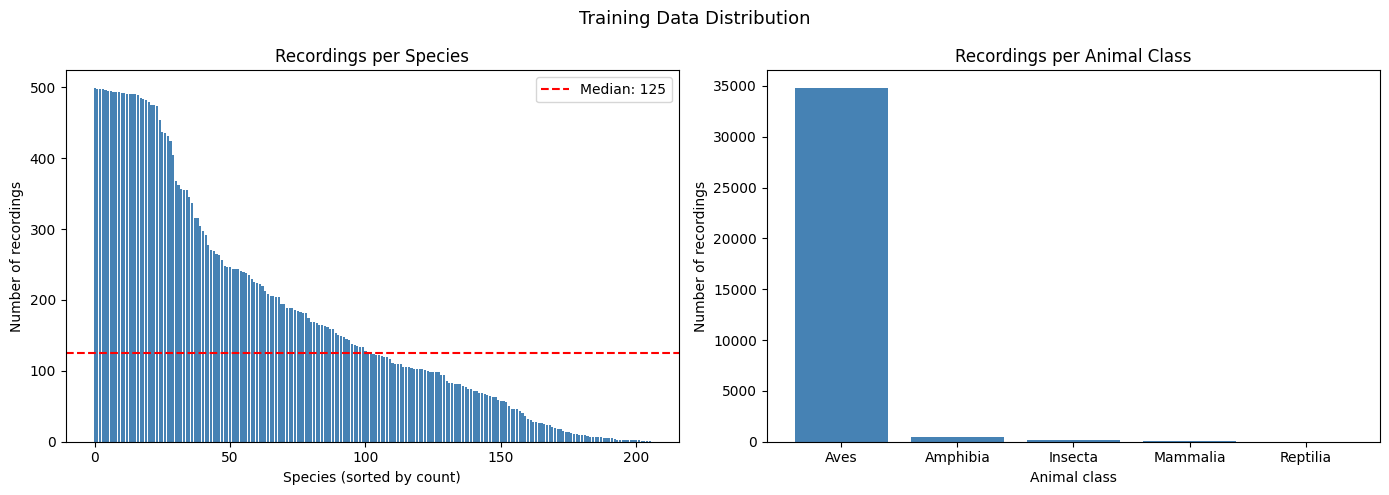

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# How many recordings does each species have?
# We expect a long tail — a few species dominate, many are underrepresented
counts = df['primary_label'].value_counts()
axes[0].bar(range(len(counts)), counts.values, color='steelblue')
axes[0].axhline(counts.median(), color='red', linestyle='--', label=f'Median: {counts.median():.0f}')
axes[0].set_title('Recordings per Species')
axes[0].set_xlabel('Species (sorted by count)')
axes[0].set_ylabel('Number of recordings')
axes[0].legend()

# The dataset is overwhelmingly birds — other classes are tiny minorities
class_counts = df['class_name'].value_counts()
axes[1].bar(class_counts.index, class_counts.values, color='steelblue')
axes[1].set_title('Recordings per Animal Class')
axes[1].set_xlabel('Animal class')
axes[1].set_ylabel('Number of recordings')

plt.suptitle('Training Data Distribution', fontsize=13)
plt.tight_layout()
plt.show()

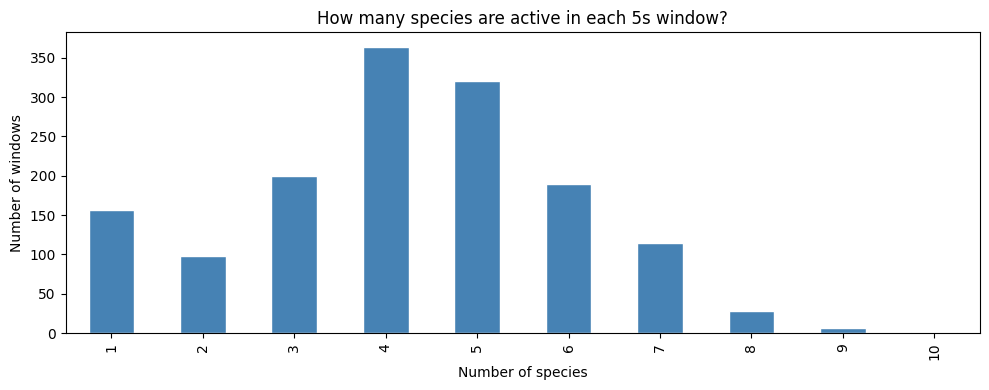

In [9]:
labels['species_list'] = labels['primary_label'].str.split(';')
labels['n_species']    = labels['species_list'].apply(len)

# test set is multilabel
labels['n_species'].value_counts().sort_index().plot(
    kind='bar', figsize=(10, 4), color='steelblue', edgecolor='white'
)
plt.title('How many species are active in each 5s window?')
plt.xlabel('Number of species')
plt.ylabel('Number of windows')
plt.tight_layout()
plt.show()

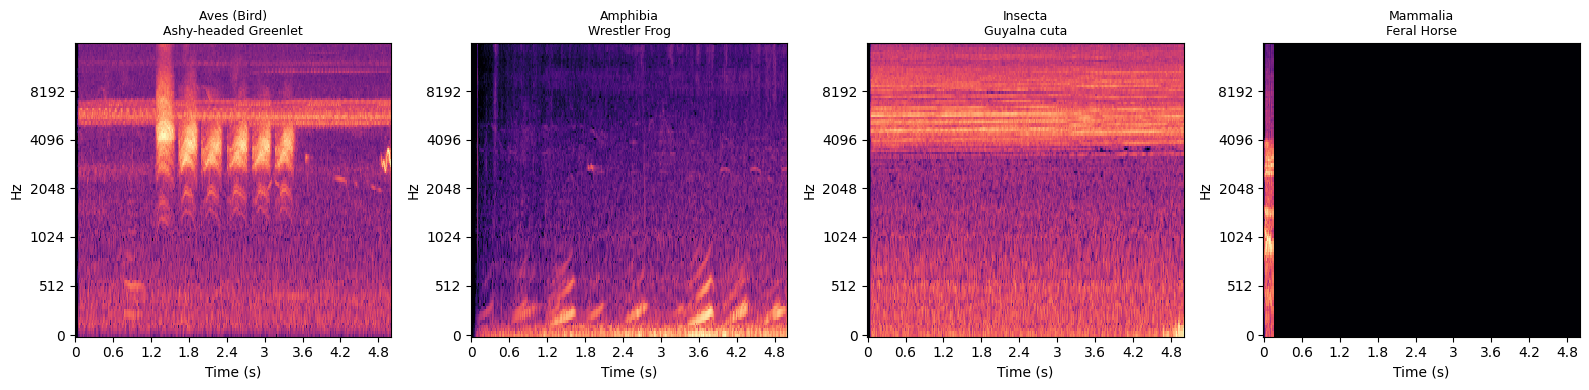

In [10]:
def load_and_convert(path):
    audio, _ = librosa.load(str(path), sr=SR, duration=DURATION)
    if len(audio) < SR * DURATION:
        audio = np.pad(audio, (0, SR * DURATION - len(audio)))
    mel = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
    return librosa.power_to_db(mel, ref=np.max)

# Pick one good example from each animal class
samples = {
    'Aves (Bird)'  : df[(df['class_name'] == 'Aves') & (df['rating'] >= 4)].iloc[0],
    'Amphibia'     : df[df['class_name'] == 'Amphibia'].iloc[0],
    'Insecta'      : df[df['class_name'] == 'Insecta'].iloc[0],
    'Mammalia'     : df[df['class_name'] == 'Mammalia'].iloc[0],
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, (cls, row) in zip(axes, samples.items()):
    mel_db = load_and_convert(TRAIN_AUDIO / row['filename'])
    librosa.display.specshow(mel_db, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(f'{cls}\n{row["common_name"][:25]}', fontsize=9)
    ax.set_xlabel('Time (s)')

plt.tight_layout()
plt.show()

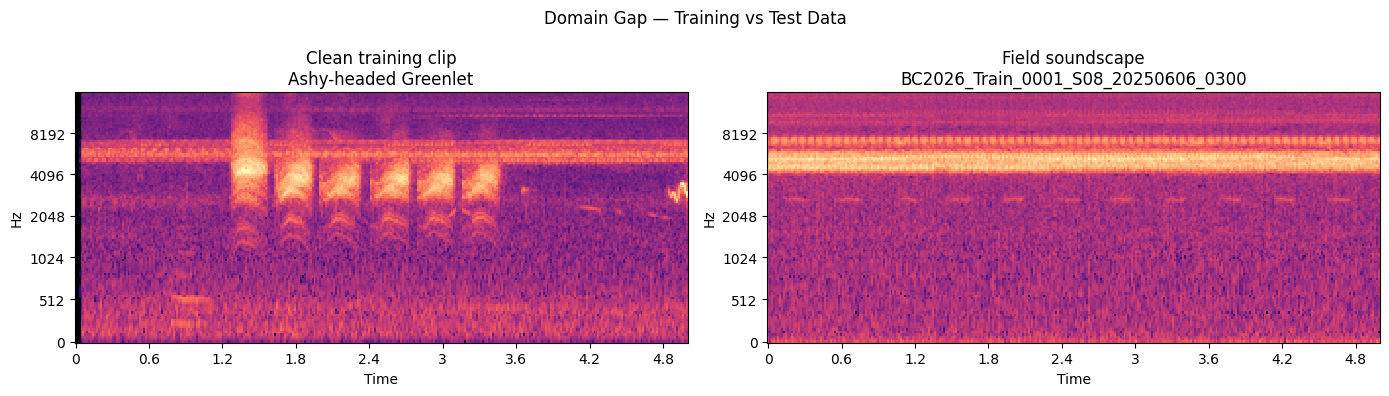

In [11]:
clean_row   = df[(df['class_name'] == 'Aves') & (df['rating'] >= 4)].iloc[0]
clean_audio, _ = librosa.load(str(TRAIN_AUDIO / clean_row['filename']), sr=SR, duration=DURATION)

sc_file     = sorted(TRAIN_SC_DIR.glob('*.ogg'))[0]
sc_audio, _ = librosa.load(str(sc_file), sr=SR, duration=DURATION)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, audio, title in [
    (axes[0], clean_audio, f'Clean training clip\n{clean_row["common_name"]}'),
    (axes[1], sc_audio,    f'Field soundscape\n{sc_file.name[:35]}')
]:
    mel    = librosa.feature.melspectrogram(y=audio, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    librosa.display.specshow(mel_db, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', ax=ax)
    ax.set_title(title)

plt.suptitle('Domain Gap — Training vs Test Data', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
# ── Model & Training Config ────────────────────────────────
NUM_CLASSES    = len(tax)          # 234
BATCH_SIZE     = 16
EPOCHS         = 5
LR             = 1e-3
DEVICE         = 'cuda' if torch.cuda.is_available() else 'cpu'
MODEL_NAME     = 'efficientnet_b0'
TRAINING_MODE  = True              # False at submission

# Label mapping — taxonomy order defines column order in submission
species_list   = tax['primary_label'].astype(str).tolist()
species_to_idx = {sp: i for i, sp in enumerate(species_list)}

print(f'Device       : {DEVICE}')
print(f'Classes      : {NUM_CLASSES}')
print(f'Training mode: {TRAINING_MODE}')

Device       : cpu
Classes      : 234
Training mode: True


In [13]:
def load_audio(path):
    audio, _ = librosa.load(str(path), sr=SR, duration=DURATION)
    # pad if shorter than 5 seconds
    if len(audio) < SR * DURATION:
        audio = np.pad(audio, (0, SR * DURATION - len(audio)))
    return audio

def is_silent(audio, threshold=0.01):
    return np.max(np.abs(audio)) < threshold

def audio_to_melspec(audio):
    mel    = librosa.feature.melspectrogram(
                y=audio, sr=SR, n_mels=N_MELS,
                n_fft=N_FFT, hop_length=HOP_LENGTH,
                fmin=FMIN, fmax=FMAX)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # normalize to [0, 1]
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-6)
    return mel_db.astype(np.float32)

sample_audio = load_audio(TRAIN_AUDIO / df.iloc[0]['filename'])
sample_spec  = audio_to_melspec(sample_audio)
print(f'Audio shape : {sample_audio.shape}')
print(f'Spec shape  : {sample_spec.shape}')
print(f'Spec range  : [{sample_spec.min():.2f}, {sample_spec.max():.2f}]')

Audio shape : (160000,)
Spec shape  : (128, 313)
Spec range  : [0.00, 1.00]


In [14]:
class BirdDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = TRAIN_AUDIO / row['filename']
        audio = load_audio(path)

        # skip silent files by returning zeros
        if is_silent(audio):
            audio = np.zeros(SR * DURATION, dtype=np.float32)

        spec  = audio_to_melspec(audio)
        spec  = np.stack([spec, spec, spec], axis=0)

        target    = np.zeros(NUM_CLASSES, dtype=np.float32)
        label_str = str(row['primary_label'])
        if label_str in species_to_idx:
            target[species_to_idx[label_str]] = 1.0

        return torch.tensor(spec), torch.tensor(target)

In [15]:
counts = df['primary_label'].value_counts()
valid_df = df[df['primary_label'].isin(counts[counts > 1].index)]

train_df, val_df = train_test_split(valid_df, test_size=0.1, stratify=valid_df['primary_label'], random_state=42)
train_ds = BirdDataset(train_df)
val_ds = BirdDataset(val_df)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

Train batches : 2000
Val batches   : 223


In [16]:
class BirdClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model(
            MODEL_NAME, pretrained=True, num_classes=NUM_CLASSES
        )

    def forward(self, x):
        return self.backbone(x)


model = BirdClassifier().to(DEVICE)
print(f'Model    : {MODEL_NAME}')
print(f'Params   : {sum(p.numel() for p in model.parameters()):,}')
print(f'Output   : {NUM_CLASSES} classes')

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

Model    : efficientnet_b0
Params   : 4,307,302
Output   : 234 classes


In [ ]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

def train_one_epoch(model, loader, epoch):
    model.train()
    total_loss = 0
    for batch_idx, (specs, targets) in enumerate(loader):
        specs, targets = specs.to(DEVICE), targets.to(DEVICE)

        optimizer.zero_grad()
        logits = model(specs)
        loss   = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 100 == 0:
            print(f'  Epoch {epoch} | Batch {batch_idx}/{len(loader)} | Loss: {loss.item():.4f}')

    return total_loss / len(loader)


def validate(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for specs, targets in loader:
            specs, targets = specs.to(DEVICE), targets.to(DEVICE)
            logits         = model(specs)
            total_loss    += criterion(logits, targets).item()
    return total_loss / len(loader)


if TRAINING_MODE:
    best_val_loss = float('inf')

    for epoch in range(1, EPOCHS + 1):
        print(f'\nEpoch {epoch}/{EPOCHS}')
        train_loss = train_one_epoch(model, train_loader, epoch)
        val_loss   = validate(model, val_loader)

        print(f'  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pt')
            print('  → Best model saved')


Epoch 1/5
  Epoch 1 | Batch 0/2000 | Loss: 0.7168
  Epoch 1 | Batch 100/2000 | Loss: 0.0251
  Epoch 1 | Batch 200/2000 | Loss: 0.0256
  Epoch 1 | Batch 300/2000 | Loss: 0.0261
